In [1]:
from google.colab import files

uploaded = files.upload()


Saving superhero-dataset.zip to superhero-dataset.zip


In [3]:
!unzip superhero-dataset.zip

Archive:  superhero-dataset.zip
   creating: superhero-dataset/
   creating: superhero-dataset/batman/
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-47-24.png  
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-08-55.png  
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-08-38.png  
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-08-28.png  
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-08-25.png  
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-08-21.png  
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-08-15.png  
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-07-40.png  
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-07-29.png  
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-07-21.png  
  inflating: superhero-dataset/batman/Screenshot from 2025-12-29 09-05-29.png  
  inflating: supe

## Step1 : Verify the dataset structure ...

In [4]:
import os

data_dir = "/content/superhero-dataset"
os.listdir(data_dir)

['spiderman', 'superman', 'batman']

## Step 2: Define image **normalized tensors of equal size**


In [7]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

As these numbers match **imagenet** which is pretrained models expect.


## Step 3: Create dataset & dataloaders

Use **ImageFolder** (it automatically assigns the labels).


In [9]:
from torchvision.datasets import ImageFolder

from torch.utils.data import DataLoader, random_split

full_dataset = ImageFolder(root=data_dir, transform=train_transform)

class_names = full_dataset.classes
num_classes = len(class_names)

print(class_names)

['batman', 'spiderman', 'superman']


### Split the dataset



In [12]:
train_size = int(0.8 * len(full_dataset))

val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size]
)

# Validation should NOT use the augumenations
val_dataset.dataset.transform = test_transform

### DataLoaders



In [15]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

print(train_loader)
print(val_loader)


### Step 4: Load a pretrained model ( transfer learning)
This is **right move** for our small dataset size .... 😢

In [18]:
import torch
import torch.nn as  nn
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet18(weights="IMAGENET1K_V1")

# Freeze backbone
for param in model.parameters():
  param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 66.0MB/s]


## Step 4: Defining the loss, optimizer, and metric


In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

### Stpe 6: Training loop (core ML skill)

In [28]:
def train_one_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    acc = correct / len(loader.dataset)
    return total_loss / len(loader), acc


In [29]:
def evaluate(model, loader):
  model.eval()
  total_loss, correct = 0, 0

  with torch.no_grad():
    for images, labels in loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      loss = criterion(outputs, labels)

      total_loss += loss.item()
      correct += (outputs.argmax(1) == labels).sum().item()

  acc = correct / len(loader.dataset)
  return total_loss / len(loader), acc


## Step 7: Train the model


In [39]:
epochs = 10

for epoch in range(epochs):
  train_loss , train_acc = train_one_epoch(model, train_loader)
  val_loss , val_acc = evaluate(model, val_loader)

  print(f"Epoch: {epoch+1}/{epochs}")
  print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
  print(f"Val loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch: 1/10
Train Loss: 0.5234, Train Acc: 0.8943
Val loss: 0.6498, Val Acc: 0.7419
Epoch: 2/10
Train Loss: 0.4653, Train Acc: 0.9024
Val loss: 0.6006, Val Acc: 0.7097
Epoch: 3/10
Train Loss: 0.4220, Train Acc: 0.9106
Val loss: 0.5675, Val Acc: 0.7742
Epoch: 4/10
Train Loss: 0.3924, Train Acc: 0.9268
Val loss: 0.5328, Val Acc: 0.8065
Epoch: 5/10
Train Loss: 0.3354, Train Acc: 0.9431
Val loss: 0.5065, Val Acc: 0.7419
Epoch: 6/10
Train Loss: 0.3084, Train Acc: 0.9593
Val loss: 0.4829, Val Acc: 0.7742
Epoch: 7/10
Train Loss: 0.2991, Train Acc: 0.9593
Val loss: 0.4640, Val Acc: 0.8065
Epoch: 8/10
Train Loss: 0.2464, Train Acc: 0.9675
Val loss: 0.4426, Val Acc: 0.8387
Epoch: 9/10
Train Loss: 0.2493, Train Acc: 0.9593
Val loss: 0.4230, Val Acc: 0.8710
Epoch: 10/10
Train Loss: 0.2349, Train Acc: 0.9837
Val loss: 0.4097, Val Acc: 0.9032


In [40]:
from google.colab import files
files.upload()


Saving ai-generated-7700259_1280.jpg to ai-generated-7700259_1280 (1).jpg


{'ai-generated-7700259_1280 (1).jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x02\x02\x02\x03\x02\x02\x02\x03\x03\x03\x03\x04\x06\x04\x04\x04\x04\x04\x08\x06\x06\x05\x06\t\x08\n\n\t\x08\t\t\n\x0c\x0f\x0c\n\x0b\x0e\x0b\t\t\r\x11\r\x0e\x0f\x10\x10\x11\x10\n\x0c\x12\x13\x12\x10\x13\x0f\x10\x10\x10\xff\xdb\x00C\x01\x03\x03\x03\x04\x03\x04\x08\x04\x04\x08\x10\x0b\t\x0b\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\x10\xff\xc0\x00\x11\x08\x05\x00\x03U\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1e\x00\x00\x00\x07\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\xff\xc4\x00O\x10\x00\x01\x03\x02\x04\x04\x03\x06\x04\x02\x07\x05\x07\x03\x02\x07\x01\x00\x02\x03\x04\x11\x05\x06!1\x07\x12AQ\x13aq\x08\x14"2\x81\x91\x15#B\xa1R\xb1\x16$3br\xc1\xd1

In [41]:
from PIL import Image
import torch

image_path = "/content/ai-generated-7700259_1280.jpg"

img = Image.open(image_path).convert("RGB")

img_tensor = test_transform(img).unsqueeze(0).to(device)

`unsqueeze(0)`  -> adds batch dimension
Shape becomes `[1, 3, 224, 224]`

In [42]:
model.eval()

with torch.no_grad():
  outputs = model(img_tensor)
  probs = torch.softmax(outputs, dim=1)
  pred_idx = probs.argmax(dim=1).item()
pred_class = class_names[pred_idx]

confidence = probs[0][pred_idx].item()


print(f"Prediction: {pred_class}")
print(f"Confidence : {confidence:.2f}")




Prediction: batman
Confidence : 0.81


## Visualizing the prediction on multiple images


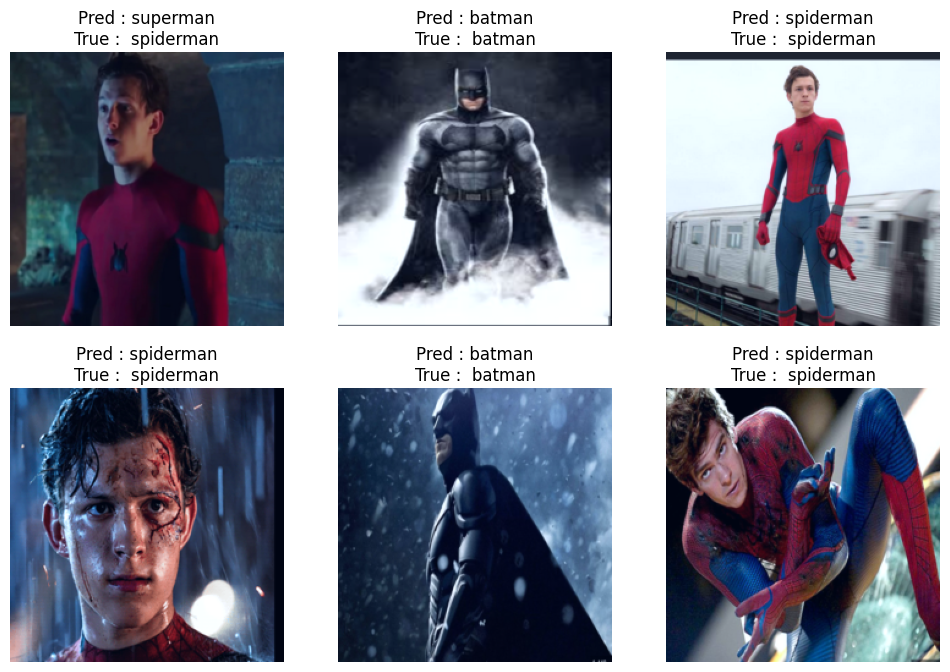

In [44]:
import matplotlib.pyplot as plt

import numpy as np

model.eval()
images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
  outputs = model(images)
  pred = outputs.argmax(1)
plt.figure(figsize=(12, 8))
for i in range(6):
  plt.subplot(2, 3, i+1)
  img = images[i].cpu().permute(1, 2, 0)
  img = img * 0.229 + 0.485
  plt.imshow(img)
  plt.title(
      f"Pred : {class_names[pred[i]]}\nTrue :  {class_names[labels[i]]}"
  )

  plt.axis("off")

plt.show()


